<a href="https://colab.research.google.com/github/rajanaids-hub/BASICS-ML/blob/main/UNIT1_BML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 1: Introduction to Machine Learning 🚀

## Learning Objectives:
By the end of this unit, you will be able to:
*   Understand the fundamental concepts of Machine Learning and its role in data-driven decision making.
*   Differentiate between various types of Machine Learning algorithms (Supervised, Unsupervised, Semi-supervised, Reinforcement Learning) and their primary applications.
*   Describe the complete end-to-end Machine Learning workflow, from data acquisition to model deployment.
*   Apply essential techniques for data preprocessing and feature engineering to prepare data for model training.
*   Identify and handle outliers in datasets.
*   Evaluate the performance of Machine Learning models using appropriate metrics and best practices.
*   Implement core ML concepts using Python libraries like pandas, numpy, and scikit-learn.
*   Critically analyze and interpret model results, understanding their advantages, limitations, and potential pitfalls.


## Topic 1: Basics of Machine Learning – Using data to make decisions

### What is Machine Learning?

Machine Learning (ML) is a subset of Artificial Intelligence (AI) that enables systems to learn from data, identify patterns, and make decisions with minimal human intervention. Think of it as teaching a computer to learn from experience, much like humans do.

#### The Core Idea: Learning from Data

At its heart, Machine Learning is about building models that can learn from historical data to make predictions or take actions on new, unseen data. Instead of explicitly programming every rule, we provide the machine with data, and it discovers the rules or patterns itself.

**Analogy**: Imagine you want to teach a child to recognize a cat. You don't give them a list of rules like "if it has whiskers, pointy ears, four legs, and a tail, it's a cat." Instead, you show them many pictures of cats and non-cats, and over time, they learn to distinguish them. Machine Learning algorithms work in a similar fashion.

### Why Machine Learning?

In today's data-rich world, ML provides powerful tools to extract insights, automate complex tasks, and solve problems that are difficult or impossible with traditional programming. Some key drivers include:

*   **Automation**: Automating repetitive or complex decision-making processes (e.g., fraud detection, quality control).
*   **Scalability**: Handling vast amounts of data and performing tasks at scale.
*   **Adaptability**: Models can adapt and improve as new data becomes available, making them suitable for dynamic environments.
*   **Discovery**: Uncovering hidden patterns and relationships in data that human analysts might miss.

### How Machines Make Decisions: A Simplified View

Let's break down the general process of how ML enables decision-making:

1.  **Data Collection**: Gathering relevant information (features) and the desired outcome (target).
2.  **Model Training**: An algorithm learns patterns from this data to build a mathematical model.
3.  **Prediction/Decision**: The trained model uses these learned patterns to make predictions or decisions on new, unseen data.

**Visual Representation (Diagram to sketch)**:

Imagine a flowchart:

`[Input Data] -- > [ML Algorithm (Learning Phase)] -- > [Trained ML Model] -- > [New Input Data] -- > [Prediction/Decision]`

### Key Terminology

*   **Dataset**: A collection of data. Typically organized into rows (samples/instances) and columns (features).
*   **Feature (or Attribute)**: An individual measurable property or characteristic of a phenomenon being observed (e.g., 'age', 'income', 'temperature').
*   **Label (or Target/Response Variable)**: The variable that we want to predict or classify (e.g., 'spam' or 'not spam', 'stock price', 'disease presence').
*   **Training Data**: The portion of the dataset used to train the ML model.
*   **Testing Data**: The portion of the dataset used to evaluate the performance of the trained model on unseen data.
*   **Model**: The mathematical function or structure learned by the ML algorithm from the training data.

### Real-World Applications of Machine Learning

ML is everywhere! Here are a few examples:

*   **Healthcare**: Disease diagnosis, drug discovery, personalized treatment plans.
*   **Finance**: Fraud detection, algorithmic trading, credit scoring.
*   **E-commerce**: Recommendation systems (e.g., "customers who bought this also bought..."), personalized marketing.
*   **Autonomous Vehicles**: Object detection, navigation, predictive maintenance.
*   **Natural Language Processing (NLP)**: Spam filtering, sentiment analysis, machine translation.
*   **Computer Vision**: Facial recognition, image classification.

### Hands-on Exercise: Simple Data-Driven Decisions with Python

Let's start with a very basic example to illustrate how we can use data to make a simple decision. We'll use a hypothetical dataset to predict if a student will pass an exam based on their study hours.


Our synthetic dataset:


,study_hours,exam_result
0,1.0,0
1,2.0,0
2,2.5,0
3,3.0,0
4,3.5,1


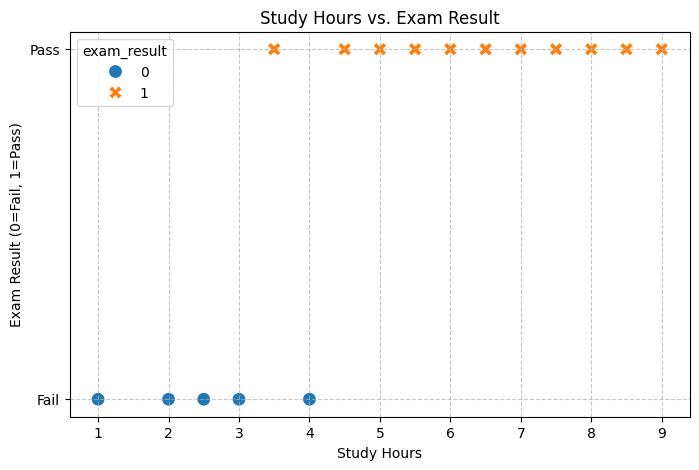

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Added this line

# Let's create a simple synthetic dataset
# Study hours and corresponding exam results (1 for Pass, 0 for Fail)
data = {
    'study_hours': [1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9],
    'exam_result': [0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

print("Our synthetic dataset:")
display(df.head())

# Visualize the data
plt.figure(figsize=(8, 5))
sns.scatterplot(x='study_hours', y='exam_result', data=df, hue='exam_result', style='exam_result', s=100)
plt.title('Study Hours vs. Exam Result')
plt.xlabel('Study Hours')
plt.ylabel('Exam Result (0=Fail, 1=Pass)')
plt.yticks([0, 1], ['Fail', 'Pass'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


#### Building a Simple Decision Rule

Looking at our scatter plot, we can observe a clear pattern: students who study for **3.5 hours or less tend to fail**, while those who study for **more than 3.5 hours tend to pass** (with one exception at 4.0 hours, which is an interesting point we'll discuss later!).

We can formulate a very basic *classification model* based on this observation:

**If `study_hours` > 3.5, predict `Pass` (1), otherwise predict `Fail` (0).**

This is a rudimentary example of a **threshold-based classifier**. While simple, it perfectly demonstrates the core idea: learning a rule from data to make predictions on new, unseen data.


In [3]:
# Let's implement our simple decision rule
threshold = 3.5

def predict_pass_fail(hours):
    if hours > threshold:
        return 1  # Predict Pass
    else:
        return 0  # Predict Fail

# Apply our prediction function to the study hours
df['predicted_result'] = df['study_hours'].apply(predict_pass_fail)

print(f"Decision Rule: If study_hours > {threshold}, predict Pass (1), else Fail (0)\n")
print("Original vs. Predicted Exam Results:")
display(df[['study_hours', 'exam_result', 'predicted_result']])

# Let's see how well our simple model performed
correct_predictions = (df['exam_result'] == df['predicted_result']).sum()
total_predictions = len(df)
accuracy = correct_predictions / total_predictions

print(f"\nCorrect Predictions: {correct_predictions} out of {total_predictions}")
print(f"Accuracy of our simple model: {accuracy:.2f}")

# Practical Tip: Even simple models can provide great insights!
# This threshold-based approach is similar to how a basic perceptron (an early neural network model) makes decisions.


Decision Rule: If study_hours > 3.5, predict Pass (1), else Fail (0)

Original vs. Predicted Exam Results:


,study_hours,exam_result,predicted_result
0,1.0,0,0
1,2.0,0,0
2,2.5,0,0
3,3.0,0,0
4,3.5,1,0
5,4.0,0,1
6,4.5,1,1
7,5.0,1,1
8,5.5,1,1
9,6.0,1,1



Correct Predictions: 14 out of 16
Accuracy of our simple model: 0.88


### Key Takeaways from Topic 1:

*   Machine Learning is about enabling systems to learn patterns from data to make decisions or predictions.
*   It's a powerful approach for automation, scalability, adaptability, and discovering insights.
*   The core process involves data collection, model training, and prediction.
*   Understanding key terminology like features, labels, datasets, and training/testing data is crucial.
*   Even a simple visual inspection of data can lead to effective decision rules.

### Exercises for Topic 1: Basics of Machine Learning

#### Theory Questions:

1.  Explain, in your own words, the fundamental difference between traditional programming and Machine Learning. Provide an example where ML would be significantly more advantageous.
2.  You are building a system to recommend movies to users. Identify potential features and a target variable for this task. Which of the 'Why Machine Learning?' drivers (Automation, Scalability, Adaptability, Discovery) are most relevant here, and why?
3.  Consider our `study_hours` vs. `exam_result` example. What are some limitations of our simple `study_hours > 3.5` decision rule? How might you intuitively improve it?

#### Coding Challenge:

1.  **Modify the Decision Rule:**
    *   In the code cell above, change the `threshold` for predicting exam results to `4.0` hours.
    *   Run the cell again and observe the new `predicted_result` column and the updated accuracy.
    *   Which threshold (`3.5` or `4.0`) yields better accuracy for our given dataset, and why do you think that is?


## Topic 2: Types of Machine Learning Algorithms

Now that we have a foundational understanding of what Machine Learning is and how it helps make data-driven decisions, let's explore the different categories of Machine Learning algorithms. Understanding these types is like knowing the different tools in a craftsman's toolbox – each suited for different kinds of problems and data. We'll primarily focus on the four main paradigms: **Supervised Learning**, **Unsupervised Learning**, **Semi-supervised Learning**, and **Reinforcement Learning**.


### 2.1 Supervised Learning: Learning from Labeled Data

**Analogy**: Imagine teaching a child to distinguish between apples and oranges. You show them a picture, tell them "this is an apple," then show another picture and say "this is an orange." You continue this process, providing both the input (the picture) and the correct output (the fruit's name). Eventually, the child learns to identify new, unseen apples and oranges on their own. This is supervised learning in a nutshell.

#### Definition

Supervised Learning is a type of Machine Learning where an algorithm learns from a **labeled dataset**. This dataset consists of input features (`X`) and corresponding correct output labels (`y`). The goal is to learn a mapping function from the input to the output so that when new, unseen input data is presented, the algorithm can accurately predict its label.

#### Key Characteristics

*   **Labeled Data**: Requires historical data with known outcomes.
*   **Direct Feedback**: The algorithm gets direct feedback on whether its predictions are correct during training.
*   **Goal**: To predict an output (label) for new input data.

#### Main Sub-types of Supervised Learning

Supervised learning problems are broadly categorized into two types:

##### 2.1.1 Classification

**Definition**: The goal is to predict a **categorical label** or class. The output variable is discrete.

**Real-world Applications**:
*   **Spam Detection**: Is an email `spam` or `not spam`?
*   **Medical Diagnosis**: Is a patient `sick` or `healthy`?
*   **Image Recognition**: Is this a `cat`, `dog`, or `bird`?
*   **Customer Churn**: Will a customer `churn` or `stay`?

**Common Algorithms (and their intuition)**:
*   **Logistic Regression**: Despite its name, it's a classification algorithm that estimates the probability of an instance belonging to a particular class.
*   **Decision Trees**: Tree-like models that split data based on features to make decisions.
*   **Support Vector Machines (SVM)**: Finds the optimal hyperplane that best separates different classes in the feature space.
*   **K-Nearest Neighbors (KNN)**: Classifies a new data point based on the majority class of its 'k' nearest neighbors in the training data.
*   **Random Forests / Gradient Boosting**: Ensemble methods that combine multiple decision trees to improve accuracy and robustness.

**Visual (Diagram to sketch)**: A scatter plot with two distinct clusters of points, each labeled with a different color/shape. Draw a line (hyperplane) separating these clusters. New, unlabeled points are then classified based on which side of the line they fall.

##### 2.1.2 Regression

**Definition**: The goal is to predict a **continuous numerical value**.

**Real-world Applications**:
*   **House Price Prediction**: Predicting the exact price of a house.
*   **Stock Market Forecasting**: Predicting future stock prices.
*   **Temperature Prediction**: Predicting tomorrow's temperature.
*   **Sales Forecasting**: Predicting next month's sales revenue.

**Common Algorithms (and their intuition)**:
*   **Linear Regression**: Finds the best-fitting straight line (or hyperplane in higher dimensions) to model the relationship between input features and the continuous output.
*   **Polynomial Regression**: Models non-linear relationships by fitting a polynomial function.
*   **Decision Tree Regressor**: Similar to classification trees, but predicts a continuous value at the leaf nodes (often the average of the target values in that node).
*   **Support Vector Regression (SVR)**: An extension of SVM for regression tasks, aiming to find a function that deviates from the true targets by no more than a certain error margin.

**Visual (Diagram to sketch)**: A scatter plot showing a trend of points. Draw a straight line (or a curve) that best fits through these points, minimizing the distance between the points and the line.

#### Advantages of Supervised Learning
*   **Predictive Power**: Highly effective for tasks where historical data with labels is available.
*   **Clear Objectives**: The goal (predicting a known target) is well-defined.
*   **Interpretability**: Many algorithms (like Decision Trees, Linear Regression) offer good interpretability, especially for simpler models.

#### Limitations of Supervised Learning
*   **Data Intensive**: Requires large amounts of accurately labeled data, which can be expensive and time-consuming to obtain.
*   **Manual Labeling Cost**: The process of labeling data can be labor-intensive.
*   **Generalization**: Poor generalization to unseen data if the training data is not representative.
*   **Overfitting**: Can easily overfit the training data if the model is too complex or the data is too sparse.

---

### 2.2 Unsupervised Learning: Discovering Hidden Patterns

**Analogy**: Imagine giving a child a box full of different colored and shaped blocks, but without telling them what they are. The child might start sorting them on their own, perhaps by color, then by shape, noticing similarities and differences. They're discovering structure in the data without any explicit instructions or labels. This is unsupervised learning.

#### Definition

Unsupervised Learning is a type of Machine Learning where an algorithm learns from **unlabeled data**. There are no pre-defined output labels. The goal is to explore the inherent structure, patterns, or groupings within the data itself.

#### Key Characteristics

*   **Unlabeled Data**: Works with data that does not have pre-assigned target variables.
*   **No Direct Feedback**: The algorithm does not receive feedback on the correctness of its output during training.
*   **Goal**: To discover hidden structures, relationships, or representations within the data.

#### Main Sub-types of Unsupervised Learning

Unsupervised learning problems primarily focus on:

##### 2.2.1 Clustering

**Definition**: The process of grouping a set of data points into clusters such that data points within the same cluster are more similar to each other than to those in other clusters.

**Real-world Applications**:
*   **Customer Segmentation**: Grouping customers based on their purchasing behavior or demographics.
*   **Document Categorization**: Grouping news articles by topic without prior tags.
*   **Anomaly Detection**: Identifying unusual patterns that don't fit into any group.
*   **Image Segmentation**: Dividing an image into regions based on pixel similarity.

**Common Algorithms (and their intuition)**:
*   **K-Means**: Partitions data into 'k' clusters, where each data point belongs to the cluster with the nearest mean (centroid).
*   **Hierarchical Clustering**: Builds a hierarchy of clusters, either by starting with individual points and merging (agglomerative) or starting with one large cluster and splitting (divisive).
*   **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**: Groups together points that are closely packed together, marking as outliers points that lie alone in low-density regions.

**Visual (Diagram to sketch)**: A scatter plot with points scattered. Draw circles or ovals around distinct groupings of points, representing clusters. The points inside each circle are similar to each other.

##### 2.2.2 Dimensionality Reduction

**Definition**: The process of reducing the number of random variables under consideration by obtaining a set of principal variables. It's about simplifying data without losing too much information.

**Real-world Applications**:
*   **Feature Selection/Extraction**: Reducing the number of features in a dataset to combat the 'curse of dimensionality' and improve model performance.
*   **Data Visualization**: Projecting high-dimensional data into 2D or 3D for easier plotting and understanding.
*   **Noise Reduction**: Removing irrelevant or redundant information.
*   **Data Compression**: Efficiently storing and transmitting data.

**Common Algorithms (and their intuition)**:
*   **Principal Component Analysis (PCA)**: Transforms data into a new coordinate system where the greatest variance by any projection lies on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on.
*   **t-distributed Stochastic Neighbor Embedding (t-SNE)**: A non-linear technique well-suited for visualizing high-dimensional datasets in 2D or 3D, preserving local structures.
*   **Autoencoders (Neural Networks)**: Neural networks trained to reconstruct their input, forcing them to learn a compressed representation in a 'bottleneck' layer.

**Visual (Diagram to sketch)**: A 3D scatter plot of points. Then, show a 2D projection of these points onto a plane, illustrating how the dimensionality is reduced while retaining their relative positions.

#### Advantages of Unsupervised Learning
*   **No Labeled Data Required**: Can work with raw, unlabeled data, which is abundant and cheaper to obtain.
*   **Discovery**: Excellent for finding hidden patterns and structures that might not be obvious to humans.
*   **Exploration**: Useful for initial data exploration and understanding.

#### Limitations of Unsupervised Learning
*   **No Ground Truth**: Hard to evaluate the performance directly as there are no labels to compare against.
*   **Interpretation**: The discovered patterns can sometimes be difficult to interpret or assign meaning to.
*   **Algorithm-Dependent**: Results can vary significantly with different algorithms or parameter choices.

---

### 2.3 Semi-Supervised Learning: The Best of Both Worlds?

**Analogy**: Imagine teaching a child to read, but you only have a few examples of labeled words (e.g., 'cat' with a picture of a cat). You also have a massive pile of unlabeled text. Semi-supervised learning is like using those few labeled examples to get a basic understanding and then leveraging the structure within the vast amount of unlabeled text to improve the learning process, perhaps by grouping similar words or inferring meanings from context.

#### Definition

Semi-Supervised Learning is a machine learning paradigm that combines a **small amount of labeled data** with a **large amount of unlabeled data** during training. It's particularly useful when obtaining labeled data is expensive or difficult, but unlabeled data is plentiful.

#### Key Characteristics

*   **Mixed Data**: Utilizes both labeled and unlabeled data.
*   **Cost-Effective**: Reduces the need for extensive manual labeling.
*   **Improved Performance**: Often achieves better performance than purely supervised learning when labeled data is scarce, and purely unsupervised learning when some guidance is needed.

#### How it Works (General Approaches)

1.  **Self-Training (or Pseudo-Labeling)**:
    *   Train a supervised model on the small labeled dataset.
    *   Use this trained model to predict labels for the unlabeled data (these are called 'pseudo-labels').
    *   Add the most confident pseudo-labeled samples to the labeled training set.
    *   Retrain the model on the expanded labeled set.
    *   Repeat until convergence or a certain number of iterations.

2.  **Generative Models**: Assume that data points belonging to the same class are generated by the same underlying process. These models can learn the joint probability distribution of features and labels from both labeled and unlabeled data.

3.  **Transductive SVM (TSVM)**: An extension of SVM that tries to find a decision boundary that not only separates the labeled data correctly but also passes through low-density regions of the unlabeled data, effectively partitioning the unlabeled data.

4.  **Graph-Based Methods**: Construct a graph where nodes are data points and edges represent similarity. Labeled information can then propagate through the graph to label unlabeled nodes.

#### Real-world Applications
*   **Web Page Classification**: Classifying web pages into categories using a few labeled examples and many unlabeled pages.
*   **Speech Recognition**: Training models with some transcribed audio and a large amount of untranscribed audio.
*   **Medical Image Analysis**: Diagnosing diseases from medical scans where only a small fraction are expertly annotated.
*   **Natural Language Processing**: Sentiment analysis, where some reviews are labeled positive/negative, but many are not.

#### Advantages of Semi-Supervised Learning
*   **Leverages Unlabeled Data**: Can significantly improve model accuracy by exploiting the information in unlabeled data.
*   **Reduces Labeling Effort**: Requires less manual labeling than fully supervised approaches.
*   **Cost-Efficient**: More economical than gathering vast amounts of labeled data.

#### Limitations of Semi-Supervised Learning
*   **Assumptions**: Often relies on assumptions about data distribution (e.g., cluster assumption, manifold assumption) which might not always hold.
*   **Error Propagation**: Pseudo-labeling can introduce errors that propagate and degrade model performance.
*   **Complexity**: Can be more complex to implement and tune than purely supervised or unsupervised methods.

---

#### Hands-on Example: Semi-Supervised Self-Training Loop

Let's implement a basic self-training loop. We'll simulate a scenario where we have a small amount of labeled data and a larger pool of unlabeled data. Our goal is to use the unlabeled data to improve a supervised classification model.

**Scenario:** Imagine we want to classify handwritten digits (0-9). We have a very small set of digits that have been correctly labeled by a human, but a vast number of other digit images that are unlabeled. Manual labeling for all of them would be too expensive.


In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load a dataset (e.g., Digits dataset)
digits = load_digits()
X, y = digits.data, digits.target

# 2. Split data into initial Labeled, Unlabeled, and Test sets
# We'll simulate having very few labeled examples

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Further split X_train_full into small labeled set and a larger unlabeled set
X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(
    X_train_full, y_train_full, test_size=0.95, random_state=42, stratify=y_train_full
)

print(f"Total dataset size: {len(X)}")
print(f"Labeled data size: {len(X_labeled)} (approx {len(X_labeled)/len(X)*100:.1f}% of total)")
print(f"Unlabeled data size: {len(X_unlabeled)}")
print(f"Test data size: {len(X_test)}\n")

# Ensure the initial split has the same number of classes for stratification
print("Initial Labeled data class distribution:")
print(pd.Series(y_labeled).value_counts().sort_index())

# For the self-training loop, we need to be able to add pseudo-labels to the unlabeled data
# We'll use a temporary copy of unlabeled data and its (unknown) original labels for evaluation purposes only.
X_unlabeled_copy = X_unlabeled.copy()
y_unlabeled_true = y_unlabeled.copy()

# Store the indices of the original unlabeled data to remove pseudo-labeled samples
unlabeled_indices = np.arange(len(X_unlabeled))


Total dataset size: 1797
Labeled data size: 71 (approx 4.0% of total)
Unlabeled data size: 1366
Test data size: 360

Initial Labeled data class distribution:
0    7
1    7
2    7
3    8
4    7
5    7
6    7
7    7
8    7
9    7
Name: count, dtype: int64


In [5]:
# 3. Define a supervised base model
# Logistic Regression is a simple, yet effective classifier.
base_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# 4. Train a model ONLY on the initial small labeled data (for baseline comparison)
model_supervised_only = base_model.fit(X_labeled, y_labeled)
supervised_only_preds = model_supervised_only.predict(X_test)
supervised_only_accuracy = accuracy_score(y_test, supervised_only_preds)
print(f"Baseline (Supervised Only) Test Accuracy: {supervised_only_accuracy:.4f}")

# --- Start Self-Training Loop ---

# Create working copies of labeled and unlabeled data for the loop
X_train_semi = X_labeled.copy()
y_train_semi = y_labeled.copy()
X_unlabeled_current = X_unlabeled.copy()
y_unlabeled_current_true = y_unlabeled_true.copy() # For tracking, not used in training

iteration = 0
added_samples_count = 0
while len(X_unlabeled_current) > 0 and iteration < 10:
    iteration += 1
    print(f"\n--- Self-Training Iteration {iteration} ---")

    # a. Train the model on the current labeled data (including pseudo-labels)
    current_model = base_model.fit(X_train_semi, y_train_semi)

    # b. Predict probabilities for the current unlabeled data
    # We use predict_proba to get confidence scores
    probabilities = current_model.predict_proba(X_unlabeled_current)

    # c. Select the most confident predictions (pseudo-labels)
    # We'll set a confidence threshold (e.g., > 90% probability for a class)
    # You can also select the top N most confident samples, or use an adaptive threshold.
    confidence_threshold = 0.95 # Higher threshold means more 'reliable' pseudo-labels

    # Get the predicted class and its confidence for each unlabeled sample
    max_probs = np.max(probabilities, axis=1)
    predicted_classes = np.argmax(probabilities, axis=1)

    # Find samples that meet the confidence threshold
    confident_indices = np.where(max_probs >= confidence_threshold)[0]

    if len(confident_indices) == 0:
        print("No confident samples found in this iteration. Stopping self-training.")
        break

    # d. Add confident pseudo-labeled samples to the labeled training set
    X_pseudo_labeled = X_unlabeled_current[confident_indices]
    y_pseudo_labeled = predicted_classes[confident_indices]

    X_train_semi = np.vstack((X_train_semi, X_pseudo_labeled))
    y_train_semi = np.concatenate((y_train_semi, y_pseudo_labeled))

    # e. Remove pseudo-labeled samples from the unlabeled pool
    # Create a mask for samples to keep (not pseudo-labeled)
    unlabeled_to_keep_mask = np.ones(len(X_unlabeled_current), dtype=bool)
    unlabeled_to_keep_mask[confident_indices] = False

    X_unlabeled_current = X_unlabeled_current[unlabeled_to_keep_mask]
    y_unlabeled_current_true = y_unlabeled_current_true[unlabeled_to_keep_mask]

    added_samples_this_iter = len(confident_indices)
    added_samples_count += added_samples_this_iter

    print(f"Added {added_samples_this_iter} pseudo-labeled samples.")
    print(f"Remaining unlabeled data: {len(X_unlabeled_current)}")
    print(f"Current Labeled data size (including pseudo-labels): {len(X_train_semi)}")

    # Evaluate current model on test set to see performance trend
    semi_supervised_preds = current_model.predict(X_test)
    semi_supervised_accuracy = accuracy_score(y_test, semi_supervised_preds)
    print(f"Current Semi-Supervised Test Accuracy: {semi_supervised_accuracy:.4f}")

print(f"\n--- Self-Training Complete ---")
print(f"Total pseudo-labeled samples added: {added_samples_count}")
print(f"Final Semi-Supervised Test Accuracy: {semi_supervised_accuracy:.4f}")

# Compare with baseline
print(f"Baseline (Supervised Only) Test Accuracy: {supervised_only_accuracy:.4f}")

# Practical Tip: The choice of confidence_threshold, the base_model, and the stopping criteria
# are critical hyperparameters in self-training. Experimentation is key!

# Common Pitfall: If the initial supervised model is very poor, it might generate incorrect pseudo-labels
# which can degrade performance in subsequent iterations (error propagation).


Baseline (Supervised Only) Test Accuracy: 0.8528

--- Self-Training Iteration 1 ---
Added 776 pseudo-labeled samples.
Remaining unlabeled data: 590
Current Labeled data size (including pseudo-labels): 847
Current Semi-Supervised Test Accuracy: 0.8528

--- Self-Training Iteration 2 ---
Added 230 pseudo-labeled samples.
Remaining unlabeled data: 360
Current Labeled data size (including pseudo-labels): 1077
Current Semi-Supervised Test Accuracy: 0.8611

--- Self-Training Iteration 3 ---
Added 57 pseudo-labeled samples.
Remaining unlabeled data: 303
Current Labeled data size (including pseudo-labels): 1134
Current Semi-Supervised Test Accuracy: 0.8639

--- Self-Training Iteration 4 ---
Added 25 pseudo-labeled samples.
Remaining unlabeled data: 278
Current Labeled data size (including pseudo-labels): 1159
Current Semi-Supervised Test Accuracy: 0.8639

--- Self-Training Iteration 5 ---
Added 17 pseudo-labeled samples.
Remaining unlabeled data: 261
Current Labeled data size (including pseudo-

### 2.4 Reinforcement Learning: Learning by Doing

**Analogy**: Imagine training a dog. You don't tell the dog step-by-step what to do to sit or fetch. Instead, you provide rewards (treats, praise) for desired behaviors and sometimes mild punishments (a firm 'no') for undesirable ones. The dog learns through trial and error, figuring out which actions maximize its rewards. This is the essence of Reinforcement Learning.

#### Definition

Reinforcement Learning (RL) is a type of Machine Learning where an **agent** learns to make a sequence of decisions in an **environment** to maximize a cumulative **reward**. The agent learns through interaction, trying different actions and observing the consequences, without explicit programming or labeled data.

#### Key Components

*   **Agent**: The learner or decision-maker.
*   **Environment**: The world in which the agent operates.
*   **State (`S`)**: The current situation of the agent in the environment.
*   **Action (`A`)**: A move made by the agent within the environment.
*   **Reward (`R`)**: A feedback signal (positive or negative) from the environment, indicating the desirability of an action.
*   **Policy (`π`)**: A strategy that maps states to actions; essentially, what the agent should do in a given state.
*   **Value Function**: Predicts the long-term return (total future reward) of a state or an action under a policy.

**Visual (Diagram to sketch)**: A loop diagram. Start with 'Agent' -> 'Action' -> 'Environment' -> 'New State + Reward' -> 'Agent'. Emphasize the continuous interaction and feedback loop.

#### How it Works

1.  **Observation**: The agent observes its current state in the environment.
2.  **Action Selection**: Based on its current policy, the agent chooses an action.
3.  **Execution**: The agent performs the action.
4.  **Reward & New State**: The environment responds by transitioning to a new state and providing a reward (or penalty) for the action taken.
5.  **Learning**: The agent updates its policy based on the received reward, aiming to choose actions that lead to higher cumulative rewards over time.

#### Main Approaches in Reinforcement Learning

1.  **Value-Based Methods**: The agent learns a value function that maps states to expected rewards (e.g., Q-learning, SARSA).
    *   **Q-Learning**: Learns an action-value function (Q-value) that gives the expected utility of taking a given action in a given state and following the optimal policy thereafter.

2.  **Policy-Based Methods**: The agent directly learns the optimal policy without explicitly learning a value function (e.g., Policy Gradients).

3.  **Actor-Critic Methods**: Combines both value-based and policy-based approaches. An 'Actor' proposes actions, and a 'Critic' evaluates those actions, guiding the actor to improve.

#### Real-world Applications
*   **Robotics**: Teaching robots to perform tasks like grasping, walking, or navigating.
*   **Autonomous Driving**: Training self-driving cars to make decisions in complex traffic scenarios.
*   **Game Playing**: Mastering complex games like Chess, Go, or Atari games (e.g., AlphaGo).
*   **Resource Management**: Optimizing energy consumption in data centers.
*   **Personalized Recommendations**: Optimizing recommendations over time based on user feedback.
*   **Financial Trading**: Developing trading strategies.

#### Advantages of Reinforcement Learning
*   **Learns from Interaction**: Can learn optimal policies in complex environments without prior knowledge.
*   **Handles Dynamic Environments**: Adaptable to changing conditions.
*   **Solves Sequential Decision-Making Problems**: Ideal for tasks requiring a series of interdependent actions.

#### Limitations of Reinforcement Learning
*   **Sample Inefficiency**: Often requires a huge number of interactions with the environment, which can be time-consuming or expensive (especially in real-world scenarios).
*   **Reward Function Design**: Designing an effective reward function can be challenging and critical for success.
*   **Exploration-Exploitation Dilemma**: Balancing between trying new actions (exploration) and sticking with known good actions (exploitation) is crucial.
*   **Computational Cost**: Can be computationally very intensive, especially for complex environments and large state/action spaces.

---

### 2.5 Summary Table: Types of Machine Learning

Let's consolidate our understanding with a summary table:

| Feature / Type          | Supervised Learning                      | Unsupervised Learning                    | Semi-Supervised Learning                 | Reinforcement Learning                   |
| :---------------------- | :--------------------------------------- | :--------------------------------------- | :--------------------------------------- | :--------------------------------------- |
| **Data Type**           | Labeled (Input + Output)                 | Unlabeled (Input only)                   | Small Labeled + Large Unlabeled          | No predefined data; learns from interaction |
| **Goal**                | Predict output for new input             | Find hidden structures/patterns          | Improve supervised learning with unlabeled data | Maximize cumulative reward through actions |
| **Feedback**            | Direct (correct answers during training) | Indirect (no correct answers)            | Mixed (direct for labeled, indirect for unlabeled) | Reward signal from environment (delayed) |
| **Common Tasks**        | Classification, Regression               | Clustering, Dimensionality Reduction     | Classification, Regression (with limited labels) | Sequential decision-making, Control, Game Playing |
| **Key Algorithms**      | Linear/Logistic Regression, Decision Trees, SVM, Random Forest | K-Means, Hierarchical Clustering, PCA, t-SNE, DBSCAN | Self-training, Generative Models, TSVM   | Q-Learning, SARSA, Policy Gradients, Actor-Critic |
| **Advantages**          | High predictive accuracy, clear objective | Discovers hidden insights, no labeling cost | Reduces labeling effort, can improve performance | Learns optimal policies in complex dynamic environments |
| **Limitations**         | Requires large labeled datasets, labeling cost | Hard to evaluate/interpret, no ground truth | Assumptions, error propagation, complexity | Sample inefficiency, reward design challenge, computational cost |
| **Real-world Example**  | Spam detection                           | Customer segmentation                    | Web page classification                  | Self-driving cars, Game AI                |

### Exercises for Topic 2: Types of Machine Learning Algorithms

#### Theory Questions:

1.  You are tasked with building a system to categorize customer feedback. Some feedback comments are tagged as 'Positive', 'Negative', or 'Neutral', but the vast majority are untagged. Which type of Machine Learning would be most appropriate, and why? Describe a possible approach you would take.
2.  Explain the 'exploration-exploitation dilemma' in Reinforcement Learning using a real-world example of your choice (e.g., a child learning a new game, a chef developing a new recipe).
3.  Differentiate between Classification and Regression in Supervised Learning, providing an example for each that was not discussed in the notes.
4.  When would you choose Dimensionality Reduction over Clustering in Unsupervised Learning, and vice-versa? Can they be used together?

#### Coding Challenge (Conceptual/Setup):

1.  **Identify ML Problem Types:** For each of the following scenarios, identify the most suitable type of Machine Learning (Supervised Classification, Supervised Regression, Unsupervised Clustering, Unsupervised Dimensionality Reduction, Semi-Supervised, or Reinforcement Learning). Briefly explain your reasoning.
    *   **Scenario A**: Building a system to predict whether a loan applicant will default (`Yes`/`No`) based on their credit history, income, and loan amount.
    *   **Scenario B**: Analyzing satellite imagery to group different land cover types (e.g., forest, urban, water) without any pre-labeled examples of these types.
    *   **Scenario C**: Training a robot to navigate a maze, where it receives a reward for reaching the exit and penalties for hitting walls.
    *   **Scenario D**: Predicting the future value of a company's stock based on historical stock prices, market trends, and economic indicators.
    *   **Scenario E**: Developing a recommendation system for online shoppers, where you have a small dataset of user ratings for specific products, and a huge catalog of unrated products, aiming to improve personalized recommendations.

---

## Topic 3: Workflow: from data to deployment (complete end-to-end ML pipeline)

Developing and deploying a Machine Learning solution is rarely a straightforward task. It involves a systematic, iterative process that goes far beyond just training a model. Understanding the complete end-to-end Machine Learning pipeline is crucial for any aspiring ML Engineer or Data Scientist. This workflow ensures that projects are robust, maintainable, and deliver real-world value.

**Analogy**: Think of building a house. You don't just start laying bricks. You need to plan, design, lay a foundation, build the structure, add plumbing and electricity, and finally, furnish it before someone can live in it. Each step depends on the previous ones, and you might even go back to refine earlier steps based on what you learn later. The ML pipeline is similar: it's a structured journey from raw materials (data) to a functional product (deployed model).

### 3.1 Overview of the ML Pipeline

The Machine Learning pipeline can be broken down into several interconnected stages. While specific names and substages might vary, the core flow remains consistent:

1.  **Problem Definition & Data Acquisition**
2.  **Data Understanding & Exploration (EDA)**
3.  **Data Preprocessing & Feature Engineering**
4.  **Model Selection & Training**
5.  **Model Evaluation**
6.  **Model Deployment & Monitoring**

**Visual (Diagram to sketch)**: A circular or linear flowchart showing these six stages with arrows indicating the flow, and also feedback loops from later stages (e.g., Evaluation back to Preprocessing or Model Selection, Monitoring back to Problem Definition).

Let's explore each stage in detail.

### 3.2 Stage 1: Problem Definition & Data Acquisition

This is arguably the most critical stage, as it sets the foundation for the entire project. A well-defined problem and reliable data are paramount.

#### 3.2.1 Problem Definition

*   **Understanding the Business Goal**: What problem are we trying to solve? How will an ML solution add value? (e.g., "Reduce customer churn by 10%," "Improve sales forecast accuracy by 15%.")
*   **Framing the ML Problem**: Translate the business goal into an ML task. Is it a classification, regression, clustering, or reinforcement learning problem? What are the inputs (features) and outputs (target)?
*   **Success Metrics**: How will we measure the success of our ML model in relation to the business goal? (e.g., Accuracy, Precision, Recall, F1-score for classification; RMSE, MAE for regression; business-specific KPIs).
*   **Constraints & Risks**: What are the ethical considerations, privacy concerns, latency requirements, budget constraints, or potential biases?

#### 3.2.2 Data Acquisition

*   **Identify Data Sources**: Where does the relevant data reside? (Databases, APIs, external files, web scraping, sensors, logs, etc.)
*   **Data Collection**: Gather raw data. This might involve querying databases, calling APIs, or setting up data streams.
*   **Data Storage**: Determine how the collected data will be stored (e.g., data lakes, data warehouses, cloud storage).

**Practical Tip**: Spend ample time here! Rushing this stage often leads to building a great solution for the *wrong problem* or struggling with inadequate data downstream. Always ask: "What data do I need to solve *this specific problem*?" and "Is this data truly available and representative?"

### 3.3 Stage 2: Data Understanding & Exploration (EDA)

Once data is acquired, the next step is to understand its characteristics, uncover insights, and identify potential issues. This is where Exploratory Data Analysis (EDA) comes into play.

*   **Descriptive Statistics**: Summarize the main characteristics of the data (mean, median, mode, standard deviation, min, max, count, unique values).
*   **Data Visualization**: Use plots and charts to reveal patterns, anomalies, relationships, and distributions. (Histograms, scatter plots, box plots, bar charts, heatmaps).
*   **Identify Data Quality Issues**: Look for missing values, inconsistent formats, outliers, erroneous entries, and potential biases.
*   **Understand Relationships**: Analyze correlations between features and the target variable, and between features themselves.
*   **Initial Feature Ideas**: Based on domain knowledge and observations, start brainstorming potential features that might be useful for the model.

**Visual (Diagram to sketch)**: A dashboard-like display showing various plots: a histogram of a numerical feature, a bar chart of a categorical feature, a scatter plot showing correlation, and a heatmap of feature correlations.

**Tools**: Pandas for data manipulation, Matplotlib and Seaborn for visualization, Profiling libraries (e.g., `pandas_profiling`, `sweetviz`).

### 3.4 Stage 3: Data Preprocessing & Feature Engineering

Raw data is rarely in a format suitable for Machine Learning algorithms. This stage transforms raw data into a clean, well-structured, and informative dataset.

#### 3.4.1 Data Preprocessing

*   **Handling Missing Values**: Imputation (mean, median, mode, predictive modeling), or removal of rows/columns.
*   **Handling Outliers**: Detection (IQR, Z-score, Isolation Forest) and treatment (capping, transformation, removal).
*   **Data Cleaning**: Correcting inconsistencies, typos, and structural errors. Standardizing formats.
*   **Data Type Conversion**: Ensuring features are in appropriate data types (e.g., numerical, categorical).
*   **Data Scaling/Normalization**: Transforming numerical features to a common scale (e.g., Min-Max Scaling, Standardization using Z-score). This is crucial for distance-based algorithms (KNN, SVM) and gradient-descent based algorithms (Logistic Regression, Neural Networks).
*   **Encoding Categorical Variables**: Converting categorical text/labels into numerical representations (e.g., One-Hot Encoding, Label Encoding, Target Encoding).

#### 3.4.2 Feature Engineering

This is the art and science of creating new features or transforming existing ones to improve the performance of Machine Learning models.

*   **Creating New Features**: Combining existing features (e.g., `BMI = weight / (height^2)`), extracting information (e.g., day of week from datetime, length of text, count of words).
*   **Feature Transformation**: Applying mathematical functions (e.g., `log`, `sqrt`) to make distributions more Gaussian or handle skewed data.
*   **Interaction Features**: Multiplying or combining features to capture non-linear relationships (e.g., `age * income`).
*   **Polynomial Features**: Creating higher-order terms (e.g., `x^2`, `x^3`) to capture non-linearities.

**Practical Tip**: Feature Engineering is often where the most significant gains in model performance come from, more so than selecting a complex algorithm. It requires strong domain knowledge and creativity. It's an iterative process!

### 3.5 Stage 4: Model Selection & Training

With clean and well-engineered features, we can now choose and train our Machine Learning model.

#### 3.5.1 Model Selection

*   **Algorithm Choice**: Select algorithms appropriate for the problem type (e.g., Logistic Regression or SVM for classification, Linear Regression or Random Forest for regression). Consider interpretability needs, data size, and computational resources.
*   **Baseline Model**: Always start with a simple model (e.g., a dummy classifier, a simple linear model) as a baseline to compare against more complex models. If a complex model doesn't significantly outperform the baseline, it might not be worth the added complexity.

#### 3.5.2 Model Training

*   **Data Splitting**: Divide the dataset into training, validation, and testing sets.
    *   **Training Set**: Used to train the model.
    *   **Validation Set**: Used to tune hyperparameters and select the best model during the development phase (prevents overfitting to the test set).
    *   **Test Set**: Held out until the very end to provide an unbiased evaluation of the final model's performance on unseen data.
*   **Hyperparameter Tuning**: Optimize the model's hyperparameters (parameters not learned from data, e.g., learning rate, number of trees, regularization strength) using techniques like Grid Search, Random Search, or Bayesian Optimization.
*   **Cross-Validation**: A technique for evaluating ML models on limited data by partitioning the data into `k` subsets, training on `k-1` subsets, and testing on the remaining subset. This process is repeated `k` times, and the results are averaged to get a more robust performance estimate.

**Visual (Diagram to sketch)**: A box showing 'Full Dataset' splitting into 'Train', 'Validation', 'Test'. Then, a magnified view of the 'Train' and 'Validation' split with 'Cross-Validation' folds illustrated.

**Tools**: Scikit-learn, TensorFlow, PyTorch for implementing and training models; GridSearchCV, RandomizedSearchCV for hyperparameter tuning.

### 3.6 Stage 5: Model Evaluation

After training, it's crucial to rigorously evaluate the model's performance to ensure it meets the defined success metrics and generalizes well to new data.

*   **Metrics Selection**: Choose appropriate evaluation metrics based on the problem type and business objective (covered in Topic 6).
    *   **Classification**: Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix.
    *   **Regression**: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), R-squared.
*   **Bias-Variance Trade-off**: Understand whether the model is underfitting (high bias) or overfitting (high variance) and take steps to address it (e.g., simplify model, add more data, use regularization, feature engineering).
*   **Error Analysis**: Don't just look at aggregate metrics; analyze where and why the model makes mistakes. This can uncover data issues or areas for further feature engineering.

**Practical Tip**: A common mistake is to only look at accuracy. For imbalanced datasets, accuracy can be misleading. Always consider multiple metrics relevant to your problem!

### 3.7 Stage 6: Model Deployment & Monitoring

Once a model is trained, evaluated, and deemed satisfactory, it needs to be integrated into a production environment where it can make predictions on new, real-world data. But the journey doesn't end there.

#### 3.7.1 Model Deployment

*   **Integration**: How will the model integrate with existing systems? (e.g., REST API endpoint, batch prediction, embedded model).
*   **Scalability**: Ensure the deployed model can handle the expected load and perform efficiently.
*   **Version Control**: Manage different versions of models and code for reproducibility and rollback.
*   **Documentation**: Document the model, its inputs, outputs, assumptions, and usage.

#### 3.7.2 Model Monitoring

*   **Performance Monitoring**: Continuously track the model's performance in production (e.g., accuracy, latency, error rates). Compare it against the initial benchmarks.
*   **Data Drift Detection**: Monitor changes in the distribution of incoming data (input features) compared to the data the model was trained on. Data drift can degrade model performance over time.
*   **Concept Drift Detection**: Monitor changes in the relationship between input features and the target variable (i.e., the underlying concept changes). This often necessitates retraining the model.
*   **Retraining Strategy**: Define a strategy for when and how to retrain the model (e.g., regularly scheduled, triggered by performance degradation or data drift).
*   **Alerting**: Set up alerts for significant drops in performance or detected data/concept drift.

**Practical Tip**: Deployment and monitoring are often overlooked but are essential for the long-term success and reliability of an ML system. A model is only as good as its performance in the real world, and the real world is constantly changing!

### Hands-on Exercise: Simulating a Basic ML Workflow with Scikit-learn

Let's walk through a simplified but complete ML pipeline using the Iris dataset, a classic for classification problems. We will cover data loading, basic EDA, preprocessing, model training, and evaluation.



--- Stage 1 & 2: Data Acquisition & Understanding ---
First 5 rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


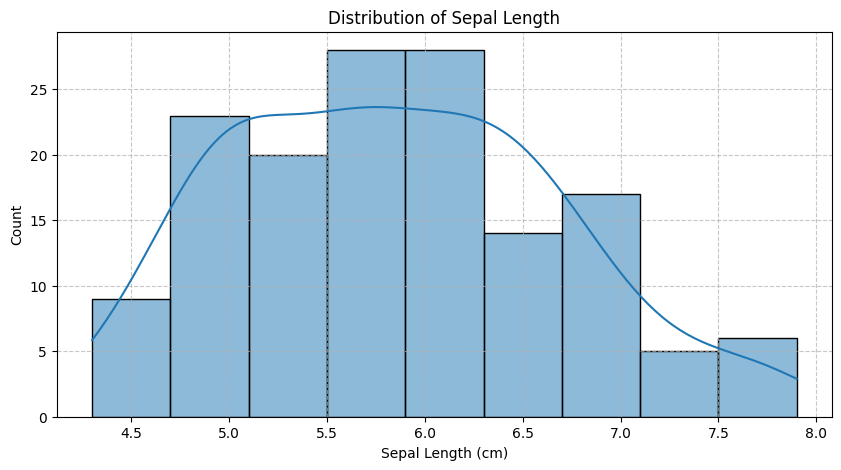

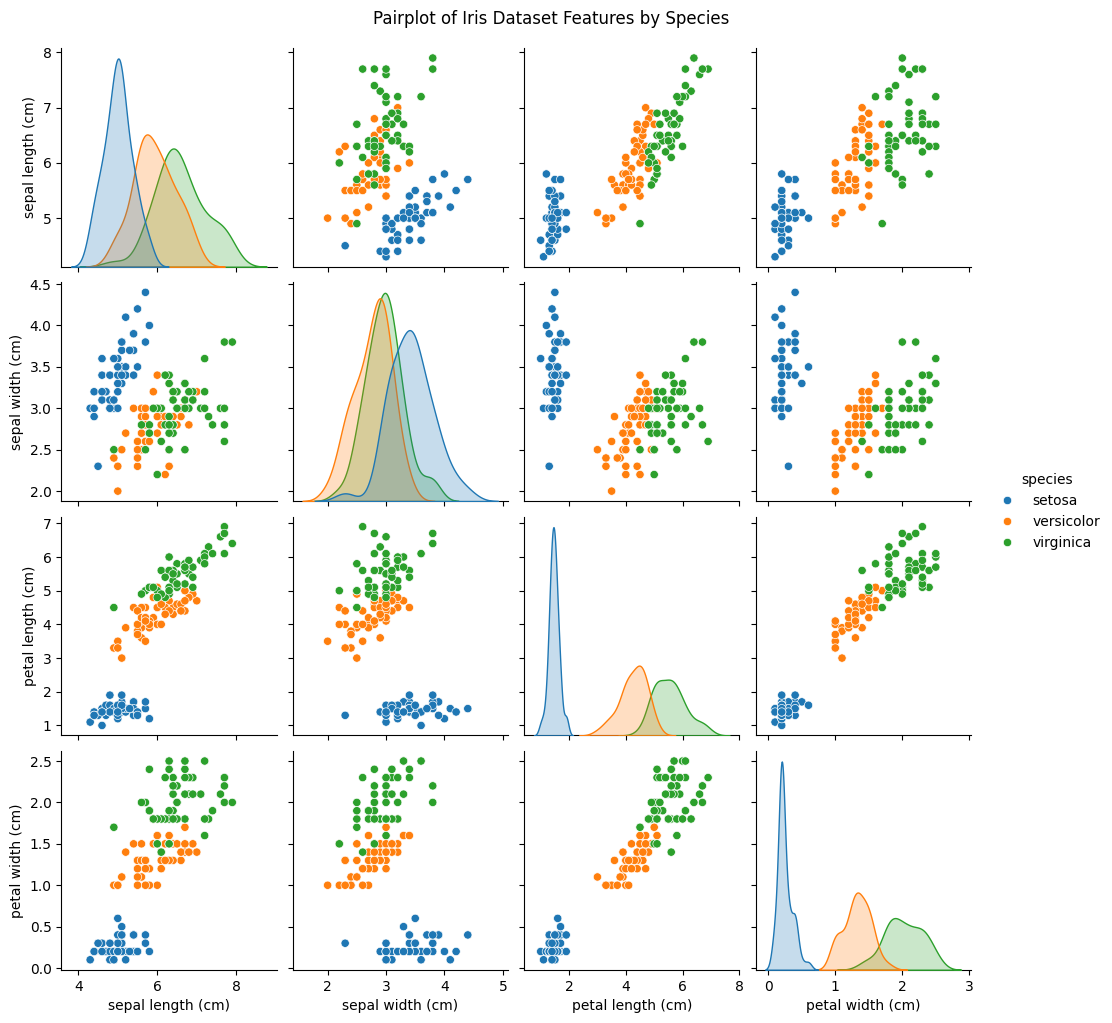

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Stage 1 & 2: Data Acquisition & Understanding (Simplified) ---
print("\n--- Stage 1 & 2: Data Acquisition & Understanding ---")

# Load the Iris dataset
# This is a classic dataset for classification, containing measurements of iris flowers.
iris = load_iris()
X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target # Target (species: setosa, versicolor, virginica)

# Create a DataFrame for easier exploration
iris_df = pd.DataFrame(data=X, columns=iris.feature_names)
iris_df['species'] = iris.target_names[y]

print("First 5 rows of the Iris dataset:")
display(iris_df.head())

print("\nDataset Info:")
iris_df.info()

print("\nDescriptive Statistics:")
display(iris_df.describe())

# Visualize feature distributions (example: sepal length)
plt.figure(figsize=(10, 5))
sns.histplot(iris_df['sepal length (cm)'], kde=True)
plt.title('Distribution of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualize relationships between features and target (example: pairplot)
sns.pairplot(iris_df, hue='species', diag_kind='kde')
plt.suptitle('Pairplot of Iris Dataset Features by Species', y=1.02) # Adjust title position
plt.show()


In [7]:
# --- Stage 3: Data Preprocessing & Feature Engineering (Simplified) ---
print("\n--- Stage 3: Data Preprocessing & Feature Engineering ---")

# For Iris, the data is already clean and numerical, so less preprocessing is needed.
# However, scaling features is good practice for many ML algorithms.

# Split data into training and testing sets first
# This simulates new, unseen data for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}\n")

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
# IMPORTANT: Fit only on training data to prevent data leakage from the test set.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler. First 5 rows of scaled training data:")
display(pd.DataFrame(X_train_scaled, columns=iris.feature_names).head())

# Note: No explicit feature engineering for this simple dataset, but in real projects,
# this is where you would create new features, handle categorical variables, etc.



--- Stage 3: Data Preprocessing & Feature Engineering ---
Training set size: 105
Test set size: 45

Features scaled using StandardScaler. First 5 rows of scaled training data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900459,-1.220248,-0.441986,-0.136610
1,0.380366,-1.879558,0.402829,0.380294
2,-0.900459,1.636764,-1.286801,-1.170419
3,1.078998,0.318143,1.191323,1.414103
4,-0.201827,-0.560937,0.177545,0.121842



--- Stage 4: Model Selection & Training ---
Training Logistic Regression model...
Model training complete.

--- Stage 5: Model Evaluation ---
Test Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.75      0.60      0.67        15
   virginica       0.67      0.80      0.73        15

    accuracy                           0.80        45
   macro avg       0.81      0.80      0.80        45
weighted avg       0.81      0.80      0.80        45



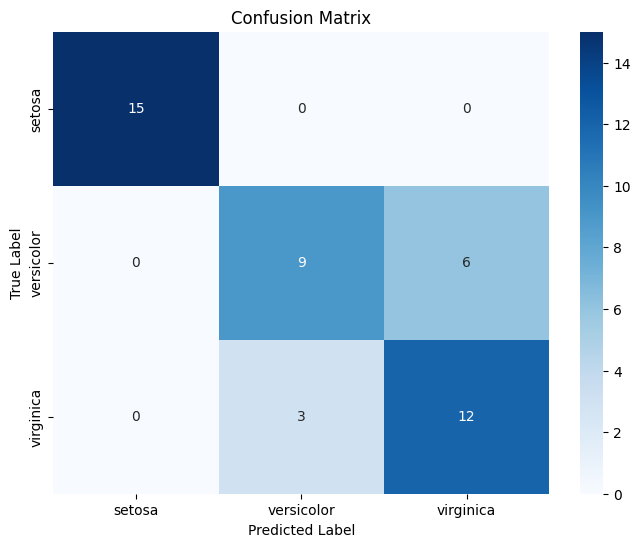


--- Stage 6: Model Deployment & Monitoring (Conceptual) ---
In a real-world scenario, the trained 'model' object would be saved (e.g., using `joblib` or `pickle`).
It would then be deployed as an API endpoint, allowing applications to send new flower measurements and receive species predictions.
Continuous monitoring would track its performance and data quality over time, triggering retraining if necessary.


In [8]:
# --- Stage 4: Model Selection & Training ---
print("\n--- Stage 4: Model Selection & Training ---")

# Model Selection: We'll use Logistic Regression, a simple yet powerful classification algorithm.
# It's a good baseline and works well with linearly separable data like Iris.
model = LogisticRegression(max_iter=200, random_state=42, solver='liblinear')

# Training the model on the scaled training data
print("Training Logistic Regression model...")
model.fit(X_train_scaled, y_train)
print("Model training complete.")

# --- Stage 5: Model Evaluation ---
print("\n--- Stage 5: Model Evaluation ---")

# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Generate a Classification Report
# This provides precision, recall, f1-score for each class
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Visualize the Confusion Matrix
# A confusion matrix shows where the model made correct and incorrect predictions
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Interpretation of Confusion Matrix:
# The diagonal elements represent the number of samples correctly classified for each class.
# Off-diagonal elements indicate misclassifications. E.g., if row 1, col 2 is 1, it means 1 sample
# of actual class 0 (setosa) was predicted as class 1 (versicolor).
# For Iris, we expect a very clean diagonal with few (if any) misclassifications.

# --- Stage 6: Model Deployment & Monitoring (Conceptual) ---
print("\n--- Stage 6: Model Deployment & Monitoring (Conceptual) ---")
print("In a real-world scenario, the trained 'model' object would be saved (e.g., using `joblib` or `pickle`).")
print("It would then be deployed as an API endpoint, allowing applications to send new flower measurements and receive species predictions.")
print("Continuous monitoring would track its performance and data quality over time, triggering retraining if necessary.")

# Example of how to save and load a model (conceptual, not executed)
# import joblib
# joblib.dump(model, 'iris_classifier_model.pkl')
# loaded_model = joblib.load('iris_classifier_model.pkl')
# new_prediction = loaded_model.predict(new_flower_measurements_scaled)


### Key Takeaways from Topic 3:

*   The ML pipeline is a structured, iterative process from problem definition to deployment and monitoring.
*   **Problem Definition & Data Acquisition** are foundational; clarify business goals and ensure data availability.
*   **Data Understanding & EDA** are crucial for gaining insights and identifying data quality issues.
*   **Data Preprocessing & Feature Engineering** transform raw data into a model-ready format, often leading to significant performance gains.
*   **Model Selection & Training** involve choosing appropriate algorithms and training them on split datasets (train, validation, test).
*   **Model Evaluation** uses relevant metrics and techniques (e.g., confusion matrix, classification report) to assess performance and identify bias/variance issues.
*   **Model Deployment & Monitoring** ensure the model operates effectively in production, guarding against data/concept drift and maintaining performance over time.

### Exercises for Topic 3: Workflow: from data to deployment

#### Theory Questions:

1.  You are building an ML model to detect fraudulent transactions. Your initial model achieves 99.5% accuracy. Why might this metric be misleading in this context, and what other metrics from 'Stage 5: Model Evaluation' would you prioritize?
2.  Explain the importance of separating data into training, validation, and test sets. What is 'data leakage', and how does scaling data (as shown in the example) help prevent it if done correctly?
3.  Describe a scenario where 'Data Drift' and 'Concept Drift' could occur for a model predicting housing prices. What actions would you take in each case as part of 'Stage 6: Model Monitoring'?

#### Coding Challenge:

1.  **Experiment with a different model:**
    *   In the 'Model Selection & Training' stage, replace `LogisticRegression` with a `DecisionTreeClassifier` (from `sklearn.tree`).
    *   Import `DecisionTreeClassifier` and instantiate it (e.g., `model = DecisionTreeClassifier(random_state=42)`).
    *   Run the model training and evaluation steps again.
    *   Compare the `accuracy` and `classification_report` results with those obtained from `LogisticRegression`. Which model performs better on the Iris dataset, and can you hypothesize why?
2.  **Simulate a Missing Value Scenario (Conceptual/Setup)**:
    *   **Goal**: Demonstrate how to handle missing values using `SimpleImputer`.
    *   **Task**: Create a copy of `iris_df`. Randomly introduce `np.nan` into, say, 10% of the 'sepal length (cm)' column in this copied DataFrame.
    *   **Hint**: You would then need to use `from sklearn.impute import SimpleImputer` and create an imputer like `imputer = SimpleImputer(strategy='mean')`. Fit it on the training data and transform both train and test sets, similar to scaling.
    *   (You don't need to retrain the model, just show the imputation step.)

---

## Topic 4: Data Preprocessing and Feature Engineering

In the Machine Learning workflow we just discussed, you saw that **Data Preprocessing & Feature Engineering** is a fundamental stage. This isn't just a chore; it's often the most critical step for building high-performing models. As the old adage goes, "Garbage In, Garbage Out" – the quality of your model is directly tied to the quality of your data.

**Analogy**: Think of raw ingredients for a gourmet meal. You wouldn't just throw raw vegetables, uncooked meat, and spices into a pot and expect a delicious dish. You need to wash, peel, chop, marinate, and season (preprocessing). You might also combine ingredients in new ways (e.g., creating a sauce or a broth) to enhance flavor (feature engineering). The better you prepare your ingredients, the more exquisite the final meal (your model's performance).

### 4.1 Data Preprocessing: Cleaning and Structuring Your Data

Data preprocessing involves a series of steps to transform raw data into a clean, consistent, and suitable format for machine learning algorithms. Most real-world datasets are incomplete, inconsistent, and prone to noise.

#### 4.1.1 Handling Missing Values

Missing data is a common issue and can severely impact model performance or even cause algorithms to fail. It occurs for various reasons (data entry errors, equipment malfunction, privacy concerns, etc.).

**Intuition**: You can't train a model on incomplete information. We need to fill in the blanks or remove the problematic data points.

**Techniques**:
*   **Deletion**: Removing rows (samples) or columns (features) with missing values.
    *   **Pros**: Simple, no data imputation assumptions.
    *   **Cons**: Can lead to significant data loss, especially if many entries have missing values. Not suitable if missingness carries information.
*   **Imputation**: Filling in missing values with estimated ones.
    *   **Mean/Median/Mode Imputation**: Replacing missing values with the mean (for numerical data without outliers), median (for numerical data with outliers or skewed distributions), or mode (for categorical data).
        *   **Pros**: Simple, preserves dataset size.
        *   **Cons**: Reduces variance, can distort relationships between variables if not handled carefully. Ignores relationships with other features.
    *   **Forward Fill / Backward Fill**: Propagating the last/next valid observation forward/backward. Useful for time series data.
    *   **Predictive Imputation**: Using other features to predict missing values (e.g., using a regression model to predict a missing numerical value).
        *   **Pros**: More sophisticated, potentially more accurate.
        *   **Cons**: More complex, computationally intensive, can introduce overfitting.
*   **Indicator Variables**: Creating a new binary feature to indicate whether a value was missing. This allows the model to learn if missingness itself is informative.

**Practical Tip**: The choice of technique depends on the nature of missingness, the amount of missing data, and the context. Visualize missing patterns using heatmaps (e.g., `sns.heatmap(df.isnull())`) to inform your strategy.

#### 4.1.2 Handling Outliers

Outliers are data points that significantly deviate from other observations. They can be legitimate but extreme values, or they can be errors. Outliers can heavily influence model training, especially for algorithms sensitive to distances and means (e.g., Linear Regression, K-Means).

**Intuition**: Extreme values can skew our understanding of the 'normal' data behavior, leading our model to make biased predictions.

**Detection Techniques**:
*   **Statistical Methods**:
    *   **Z-score**: For normally distributed data, values beyond 2 or 3 standard deviations from the mean are considered outliers.
    *   **IQR (Interquartile Range)**: For non-normally distributed data, values outside `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` are outliers.
*   **Visualization**: Box plots, scatter plots, histograms can visually reveal outliers.
*   **Model-Based Methods**:
    *   **Isolation Forest**: An unsupervised algorithm that isolates anomalies by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature.
    *   **Local Outlier Factor (LOF)**: Measures the local deviation of a given data point with respect to its neighbors. It is based on the concept of local density.

**Treatment Techniques**:
*   **Removal**: Deleting outlier data points.
    *   **Pros**: Simple.
    *   **Cons**: Can lead to data loss; only justifiable if outliers are errors.
*   **Capping (Winsorization)**: Replacing outliers with a specified percentile value (e.g., replace values above 99th percentile with the 99th percentile value).
*   **Transformation**: Applying mathematical transformations (e.g., `log`, `sqrt`) to reduce the impact of extreme values.
*   **Binning**: Grouping numerical data into bins, which can smooth out outliers.
*   **Model Choice**: Use robust models less sensitive to outliers (e.g., tree-based models like Random Forest).

**Warning**: Before treating an outlier, investigate its cause. It might represent valuable information (e.g., fraud, equipment failure).

#### 4.1.3 Data Scaling and Normalization

Many machine learning algorithms perform better or converge faster when numerical input features are scaled to a common range or distribution. This prevents features with larger numerical values from dominating the learning process.

**Intuition**: If one feature ranges from 0-1000 and another from 0-1, the model might implicitly give more weight to the first feature, regardless of its actual importance.

**Techniques**:
*   **Standardization (Z-score Normalization)**:
    *   Transforms data to have a mean of 0 and a standard deviation of 1. Formula: `(X - mean) / std_dev`.
    *   **Suitable for**: Algorithms that assume Gaussian distributions or rely on distance calculations (e.g., SVM, K-Means, Logistic Regression, Neural Networks).
*   **Min-Max Scaling (Normalization)**:
    *   Scales data to a fixed range, usually 0 to 1. Formula: `(X - min) / (max - min)`.
    *   **Suitable for**: Algorithms that don't assume a specific distribution, or when features need to be on a specific scale (e.g., image processing, some neural networks).
*   **Robust Scaling**: Scales features using statistics that are robust to outliers (median and IQR). Useful when your data contains many outliers.

**Important Note on Data Leakage**: Always fit the scaler (e.g., `scaler.fit(X_train)`) *only* on the training data and then transform both training and test data (`scaler.transform(X_train)`, `scaler.transform(X_test)`). Fitting on the entire dataset before splitting would lead to data leakage, as information from the test set would influence the scaling parameters, resulting in an overly optimistic evaluation.

#### 4.1.4 Encoding Categorical Variables

Machine learning algorithms typically work with numerical data. Categorical features (e.g., 'Color': Red, Blue, Green) need to be converted into a numerical format.

**Intuition**: Computers understand numbers, not text labels. We need a numerical representation that preserves the meaning (or lack thereof) of categories.

**Techniques**:
*   **One-Hot Encoding**:
    *   Creates new binary (0 or 1) columns for each unique category. For `n` categories, `n` new columns are created, and a 1 indicates the presence of that category. (e.g., 'Red' -> [1, 0, 0], 'Blue' -> [0, 1, 0]).
    *   **Suitable for**: Nominal categorical variables (no inherent order). Prevents algorithms from assuming an arbitrary order. Avoids multicollinearity by dropping one of the resulting columns (n-1 encoding).
    *   **Cons**: Can lead to a high-dimensional dataset if there are many unique categories, potentially causing the 'curse of dimensionality'.
*   **Label Encoding (Ordinal Encoding)**:
    *   Assigns a unique integer to each category (e.g., 'Red': 0, 'Blue': 1, 'Green': 2).
    *   **Suitable for**: Ordinal categorical variables (where categories have a meaningful order, e.g., 'Small' < 'Medium' < 'Large').
    *   **Cons**: Algorithms might incorrectly infer an ordinal relationship for nominal variables, which can negatively impact performance.
*   **Target Encoding (Mean Encoding)**:
    *   Replaces a categorical value with the mean of the target variable for that category. (e.g., 'City A' replaced by the average house price in City A).
    *   **Pros**: Creates a numerical feature, handles high cardinality (many unique categories) well.
    *   **Cons**: Prone to overfitting, especially on small datasets or when categories have few samples. Requires careful cross-validation to prevent information leakage from the target variable.

### 4.2 Feature Engineering: Creating New Insights from Data

Feature engineering is the process of using domain knowledge to extract new features from raw data. It's often where data scientists add the most value and can unlock significant performance gains that generic algorithms alone cannot achieve.

**Intuition**: Raw data usually doesn't directly represent the underlying patterns relevant to the problem. We need to craft features that make these patterns explicit and easier for the model to learn.

**Techniques**:
*   **Creating New Features from Existing Ones**:
    *   **Combinations**: `BMI = weight / (height)^2`, `Age * Income` (interaction terms).
    *   **Ratios**: `Debt-to-Income Ratio`, `Price-to-Earnings Ratio`.
    *   **Differences**: `Temperature_Max - Temperature_Min`.
    *   **Aggregations**: For transactional data, sum of purchases in the last 30 days, average transaction value.
*   **Extracting Information from Timestamps**:
    *   `Day of week`, `Month`, `Year`, `Hour of day`.
    *   `Is_weekend`, `Is_holiday`.
    *   `Time since last event`.
*   **Binning / Discretization**: Converting continuous numerical features into categorical bins (e.g., `Age` into 'Child', 'Teen', 'Adult', 'Senior').
*   **Text Feature Extraction**:
    *   `Word counts`, `Character counts`, `Length of text`.
    *   `Bag-of-Words`, `TF-IDF` (Term Frequency-Inverse Document Frequency).
    *   `Word Embeddings` (e.g., Word2Vec, GloVe).
*   **Image Feature Extraction**:
    *   `Edge detection`, `Corner detection`.
    *   `Color histograms`.
    *   Using pre-trained Convolutional Neural Networks (CNNs) as feature extractors.
*   **Polynomial Features**: Creating polynomial combinations of existing features (e.g., `x1`, `x2`, `x1^2`, `x2^2`, `x1*x2`). This can help linear models capture non-linear relationships.

**Practical Tip**: This is where creativity, domain expertise, and iterative experimentation truly shine. Don't be afraid to try many different ideas. Always validate new features to ensure they add value and don't introduce noise or complexity unnecessarily.

### Hands-on Exercise: Data Preprocessing and Feature Engineering on the Titanic Dataset

Let's apply some of these techniques to a well-known dataset: the Titanic survival dataset. We'll focus on handling missing values, encoding categorical features, and creating new features to potentially improve survival prediction.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Data Acquisition (Load the Titanic dataset)
print("\n--- 1. Data Acquisition: Loading Titanic Dataset ---")
# The Titanic dataset is often available in Seaborn or Kaggle.
# For consistency, we'll download it if not present, or use a direct link.
try:
    df_titanic = pd.read_csv('https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')
except Exception as e:
    print(f"Could not load Titanic dataset from URL, trying local: {e}")
    # Fallback for local testing if you have the file saved
    df_titanic = pd.read_csv('titanic.csv')

print("Original Titanic Data Sample:")
display(df_titanic.head())
print(f"Original dataset shape: {df_titanic.shape}")

# 2. Data Understanding (Initial EDA - Focus on missing values and types)
print("\n--- 2. Data Understanding: Initial Checks ---")
print("Missing Values (before preprocessing):")
display(df_titanic.isnull().sum())
print("Data Types:")
display(df_titanic.dtypes)

# Drop 'Name' and 'Ticket' as they are typically not directly used for modeling
# 'Cabin' has too many missing values to be easily imputed or useful in this simple example
df_titanic_processed = df_titanic.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'], errors='ignore')

# Define features (X) and target (y)
X = df_titanic_processed.drop('Survived', axis=1)
y = df_titanic_processed['Survived']

# Split data into training and testing sets (important for proper preprocessing!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


In [ ]:
# 3. Data Preprocessing & Feature Engineering
print("\n--- 3. Data Preprocessing & Feature Engineering ---")

# Identify numerical and categorical features
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# --- Preprocessing Pipeline ---

# Create a preprocessing pipeline for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Impute missing 'Age' with mean
    ('scaler', StandardScaler())                  # Scale numerical features
])

# Create a preprocessing pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute missing 'Embarked' with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # One-hot encode categorical features
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) as is
)

# --- Feature Engineering ---
# Let's create a new feature: 'FamilySize' from 'SibSp' and 'Parch'
# This will be done before the preprocessing pipeline on the original X_train/X_test

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe['FamilySize'] = X_train_fe['SibSp'] + X_train_fe['Parch'] + 1 # +1 for the passenger themselves
X_test_fe['FamilySize'] = X_test_fe['SibSp'] + X_test_fe['Parch'] + 1

# Add 'FamilySize' to numerical features list for scaling
numerical_features_with_fe = numerical_features + ['FamilySize']

# Update the preprocessor to include the new feature
preprocessor_with_fe = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_with_fe),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Explicitly drop 'SibSp' and 'Parch' as they are now combined into 'FamilySize'
)

print("Applying preprocessing and feature engineering with Pipeline...")

# Apply the preprocessing to the training and testing data
X_train_transformed = preprocessor_with_fe.fit_transform(X_train_fe)
X_test_transformed = preprocessor_with_fe.transform(X_test_fe)

print("Preprocessing and Feature Engineering complete.")
print(f"Transformed training data shape: {X_train_transformed.shape}")
print(f"Transformed testing data shape: {X_test_transformed.shape}")

# Display a snippet of the transformed data (it will be a numpy array)
print("\nFirst 5 rows of transformed training data (numerical array):")
print(X_train_transformed[:5])


In [ ]:
# 4. Model Training & 5. Model Evaluation (using the preprocessed data)
print("\n--- 4. Model Training & 5. Model Evaluation ---")

# Initialize a Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42, max_iter=200)

# Train the model on the transformed training data
print("Training Logistic Regression model on preprocessed data...")
model.fit(X_train_transformed, y_train)
print("Model training complete.")

# Make predictions on the transformed test data
y_pred = model.predict(X_test_transformed)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix for Titanic Survival Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n--- 6. Model Deployment & Monitoring (Conceptual) ---")
print("The trained 'model' object, along with the 'preprocessor_with_fe' (to transform new incoming data), would be saved.")
print("They would then be deployed together to predict survival on new passenger data.")
print("Monitoring would track prediction accuracy and detect any shifts in passenger demographics or survival rates.")


### Key Takeaways from Topic 4:

*   **Data Preprocessing** is essential for cleaning, structuring, and preparing raw data for ML algorithms.
    *   Techniques like **imputation** (mean, median, mode) address missing values.
    *   **Outlier detection** (Z-score, IQR) and treatment are crucial to prevent model bias.
    *   **Data scaling** (Standardization, Min-Max Scaling) ensures features contribute equally, especially for distance-based algorithms.
    *   **Categorical encoding** (One-Hot, Label Encoding) converts text into numerical formats algorithms can understand.
*   **Feature Engineering** involves creating new, more informative features from existing ones, often leveraging domain knowledge.
    *   This step can significantly boost model performance by making underlying patterns more explicit.
*   It's critical to apply preprocessing steps correctly (e.g., fitting scalers *only* on training data) to prevent **data leakage**.
*   Using `sklearn.pipeline` and `ColumnTransformer` helps organize and streamline these complex preprocessing steps, making the workflow robust and reproducible.

### Exercises for Topic 4: Data Preprocessing and Feature Engineering

#### Theory Questions:

1.  Explain why it's generally better to use the median for imputing missing numerical values when outliers are present, rather than the mean. Provide an example.
2.  Discuss the trade-offs between One-Hot Encoding and Label Encoding. In what specific scenarios would you prefer one over the other?
3.  Why is feature scaling important for algorithms like K-Nearest Neighbors or Support Vector Machines, but less critical for tree-based models like Decision Trees or Random Forests?

#### Coding Challenge:

1.  **Experiment with different imputation strategies:**
    *   In the provided Titanic example, change the `strategy` for `SimpleImputer` for numerical features from `'mean'` to `'median'`.
    *   Re-run the entire preprocessing and model training/evaluation. Observe if there's any change in the model's accuracy or classification report. Explain any observed differences.
2.  **Add another engineered feature:**
    *   Try creating a new feature like `IsAlone` (1 if `FamilySize` is 1, else 0) or `Title` (extracted from the 'Name' column, e.g., Mr., Mrs., Miss, Master).
    *   Integrate this new feature into the preprocessing pipeline (remember to handle it correctly, e.g., for 'Title' it would be a new categorical feature needing one-hot encoding).
    *   Re-train and evaluate the model. Did this new feature improve performance? Why or why not?

---